###  Data Loading and Initial Overview

First, we will load the `amazon_sales_dataset.csv` file into a pandas DataFrame. This allows us to inspect its structure and contents, which is crucial for planning our dashboard visualizations.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/sample_data/amazon_sales_dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,school,Home,Furniture,Davis LLC,2,36138.76,0.24,112.96,55043.8752,COD
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,step,Electronics,Laptop,"Sandoval, Buckley and Solis",1,18487.99,0.06,114.15,17492.8606,Card
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,bit,Home,Kitchen,"Key, Bautista and Bowen",1,1742.25,0.10,40.47,1608.4950,UPI


###  Data Cleaning and Preprocessing

To ensure our data is ready for analysis and visualization, we need to convert date columns to the appropriate datetime format. This step is essential for accurate time-series analysis in our dashboard.

In [3]:
# Convert date columns to datetime objects
date_columns = ['order_date', 'ship_date', 'delivery_date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# Display the DataFrame information after conversion to confirm data types
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        10000 non-null  object        
 1   order_date      10000 non-null  datetime64[ns]
 2   ship_date       10000 non-null  datetime64[ns]
 3   delivery_date   10000 non-null  datetime64[ns]
 4   order_status    10000 non-null  object        
 5   customer_id     10000 non-null  object        
 6   customer_name   10000 non-null  object        
 7   country         10000 non-null  object        
 8   state           10000 non-null  object        
 9   city            10000 non-null  object        
 10  product_id      10000 non-null  object        
 11  product_name    10000 non-null  object        
 12  category        10000 non-null  object        
 13  sub_category    10000 non-null  object        
 14  brand           10000 non-null  object        
 15  qua

None

###  Feature Engineering and Missing Values Check

To enrich our dataset for sales trend analysis, we'll extract additional time-based features such as year, month, and day of the week from the `order_date` column. Following this, we'll check for any missing values to ensure the dataset's integrity for dashboard creation.

In [4]:
# Extract year, month, and day of week from order_date
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month_name()
df['order_day_of_week'] = df['order_date'].dt.day_name()

# Display the first few rows with the new features
display(df[['order_date', 'order_year', 'order_month', 'order_day_of_week']].head())

# Check for missing values across the DataFrame
display(df.isnull().sum())

,order_date,order_year,order_month,order_day_of_week
0,2026-01-31,2026,January,Saturday
1,2026-01-20,2026,January,Tuesday
2,2026-01-15,2026,January,Thursday
3,2026-01-18,2026,January,Sunday
4,2026-01-27,2026,January,Tuesday


,0
order_id,0
order_date,0
ship_date,0
delivery_date,0
order_status,0
customer_id,0
customer_name,0
country,0
state,0
city,0


###  Data Analysis for Dashboard

With our data now cleaned and preprocessed, we can begin the analytical phase. This involves calculating key sales metrics, identifying trends, and preparing aggregated data suitable for dashboard visualizations. We will focus on total sales, average order value, sales distribution by various dimensions, and other relevant KPIs to meet the project's objectives for a sales overview and executive insights.

# Calculate key sales metrics
total_sales = df['total_sales'].sum()
average_order_value = df['total_sales'].mean()
total_orders = df['order_id'].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Total Number of Orders: {total_orders}")

# Sales trend over time (e.g., monthly sales)
monthly_sales = df.groupby('order_month')['total_sales'].sum().sort_values(ascending=False)
print("\nMonthly Sales:")
display(monthly_sales)

In [5]:
# Calculate key sales metrics
total_sales = df['total_sales'].sum()
average_order_value = df['total_sales'].mean()
total_orders = df['order_id'].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Total Number of Orders: {total_orders}")

# Sales trend over time (e.g., monthly sales)
monthly_sales = df.groupby('order_month')['total_sales'].sum().sort_values(ascending=False)
print("\nMonthly Sales:")
display(monthly_sales)

Total Sales: $642,129,105.55
Average Order Value: $64,212.91
Total Number of Orders: 10000

Monthly Sales:


,total_sales
order_month,
January,4.899901e+08
February,1.521390e+08


Now, let's get some basic information about the dataset, including data types and non-null values, to identify any immediate cleaning needs.

In [2]:
# Display concise summary of the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  object 
 1   order_date      10000 non-null  object 
 2   ship_date       10000 non-null  object 
 3   delivery_date   10000 non-null  object 
 4   order_status    10000 non-null  object 
 5   customer_id     10000 non-null  object 
 6   customer_name   10000 non-null  object 
 7   country         10000 non-null  object 
 8   state           10000 non-null  object 
 9   city            10000 non-null  object 
 10  product_id      10000 non-null  object 
 11  product_name    10000 non-null  object 
 12  category        10000 non-null  object 
 13  sub_category    10000 non-null  object 
 14  brand           10000 non-null  object 
 15  quantity        10000 non-null  int64  
 16  unit_price      10000 non-null  float64
 17  discount        10000 non-null  

None

### Top 5 Countries by Sales Visualization

To highlight the top-performing regions, we will visualize the total sales for the top 5 countries using a bar chart. This will quickly show which countries are driving the most revenue.

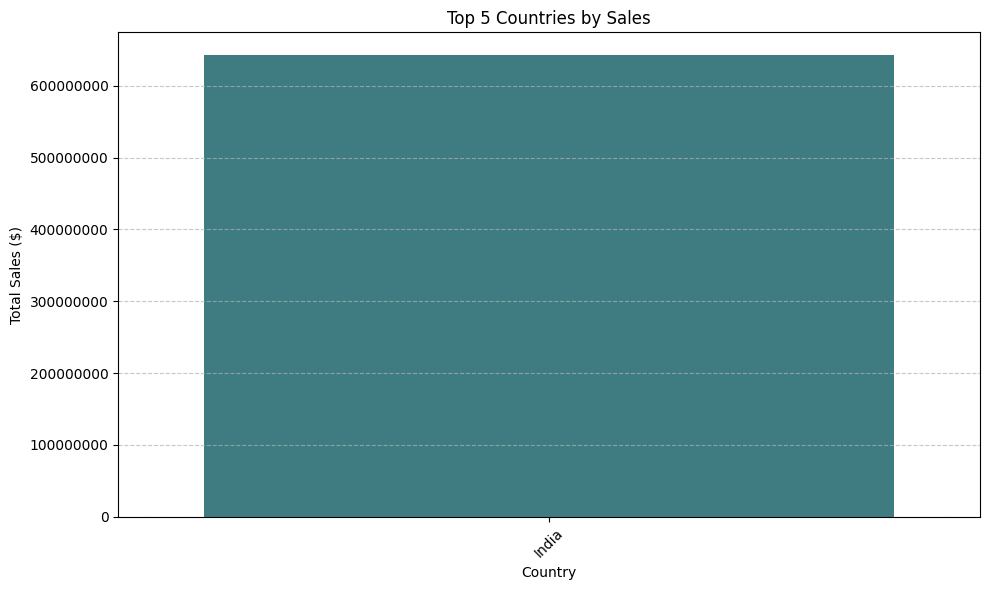

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(x='country', y='total_sales', data=top_countries, palette='crest', hue='country', legend=False)
plt.title('Top 5 Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###  Key Performance Indicators (KPIs) for Executives

This section presents a summary of key performance indicators designed to give executives a quick and clear understanding of the business's sales performance. We will cover overall sales, average order value, and top-performing segments like categories, countries, and customers.

In [8]:
print("### Core Sales KPIs:")
print(f"- Total Sales: ${total_sales:,.2f}")
print(f"- Average Order Value: ${average_order_value:,.2f}")
print(f"- Total Number of Orders: {total_orders}")

# Top 5 Categories by Sales
top_categories = df.groupby('category')['total_sales'].sum().nlargest(5).reset_index()
print("\n### Top 5 Categories by Sales:")
display(top_categories)

# Top 5 Countries by Sales
top_countries = df.groupby('country')['total_sales'].sum().nlargest(5).reset_index()
print("\n### Top 5 Countries by Sales:")
display(top_countries)

# Top 5 Customers by Total Sales
top_customers = df.groupby('customer_name')['total_sales'].sum().nlargest(5).reset_index()
print("\n### Top 5 Customers by Total Sales:")
display(top_customers)

### Core Sales KPIs:
- Total Sales: $642,129,105.55
- Average Order Value: $64,212.91
- Total Number of Orders: 10000

### Top 5 Categories by Sales:


,category,total_sales
0,Electronics,2.193563e+08
1,Home,2.147638e+08
2,Fashion,2.080091e+08



### Top 5 Countries by Sales:


,country,total_sales
0,India,6.421291e+08



### Top 5 Customers by Total Sales:


,customer_name,total_sales
0,Megan Johnson,519128.2180
1,John Smith,437475.7072
2,Thomas Johnson,434161.2441
3,Jason Smith,421137.4910
4,Jennifer Brown,415018.8828


### Monthly Sales Visualization

To better understand the sales trends over time, we will visualize the monthly sales data using a bar chart. This will clearly show which months had the highest and lowest sales, contributing to our sales overview.

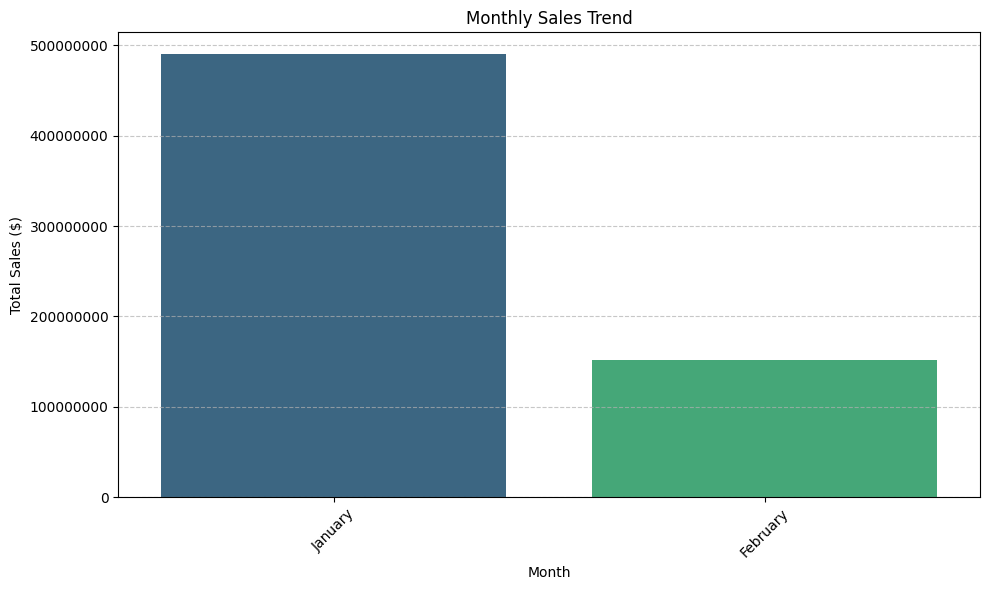

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette='viridis', hue=monthly_sales.index, legend=False)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top Customers by Sales Visualization

To gain customer insights, we will visualize the total sales contributed by our top 5 customers using a bar chart. This helps in identifying high-value customers.

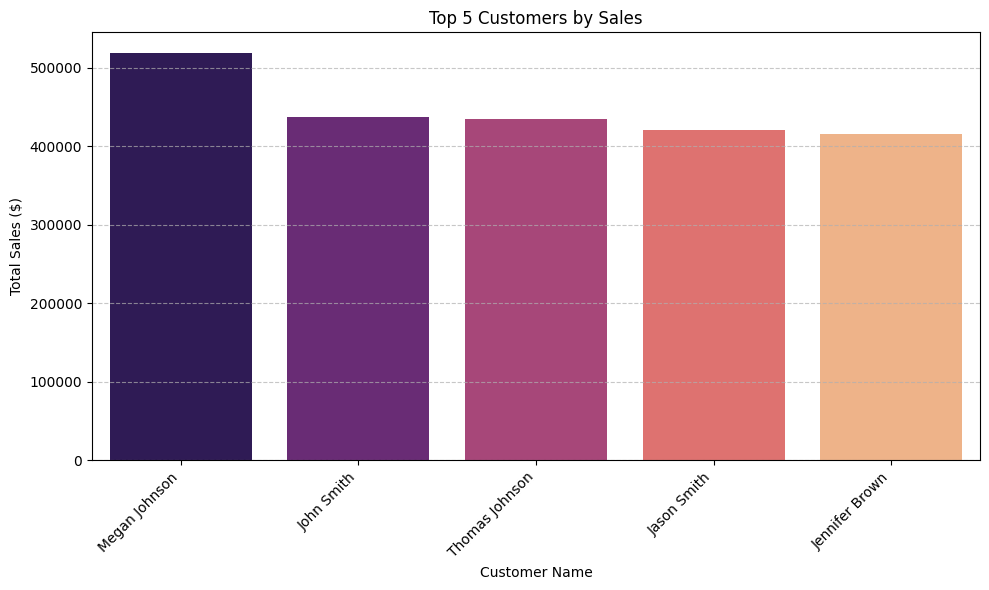

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x='customer_name', y='total_sales', data=top_customers, palette='magma', hue='customer_name', legend=False)
plt.title('Top 5 Customers by Sales')
plt.xlabel('Customer Name')
plt.ylabel('Total Sales ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sales by Category Visualization

To understand the sales distribution across different product categories, we will visualize the total sales for each category using a bar chart. This helps in identifying the best-performing product segments.

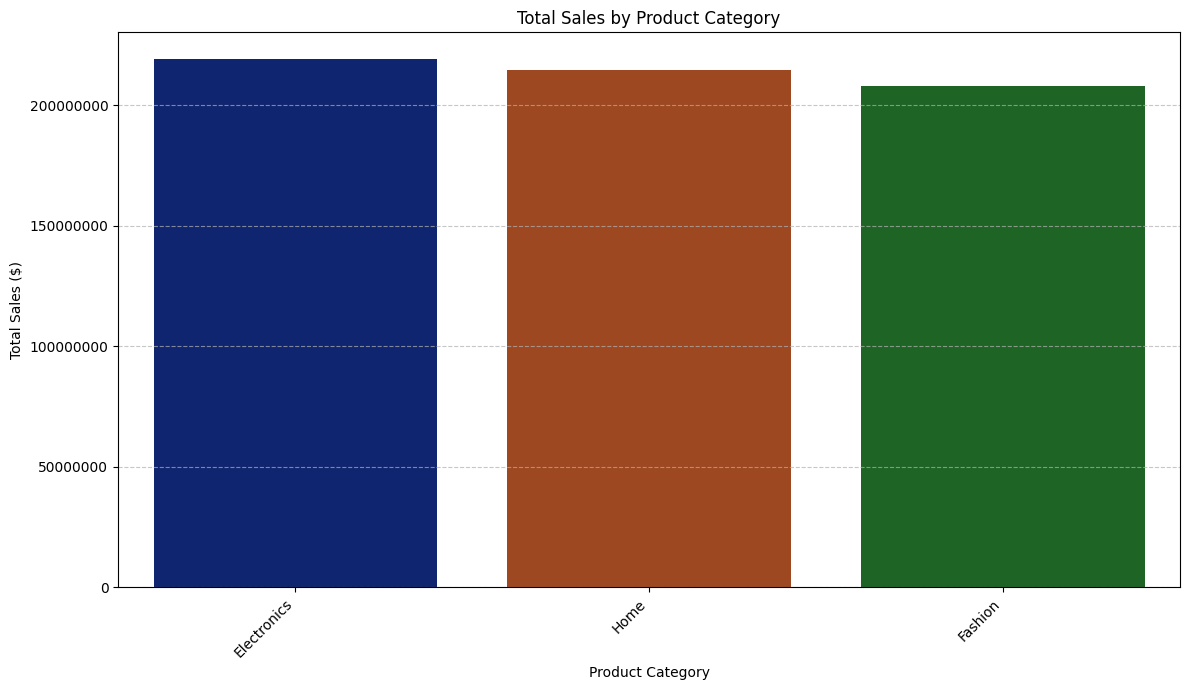

In [11]:
plt.figure(figsize=(12, 7))
sns.barplot(x='category', y='total_sales', data=top_categories, palette='dark', hue='category', legend=False)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sales by Sub-Category Visualization

To gain a more granular understanding of product performance, we will visualize the total sales for each sub-category using a bar chart. This helps in identifying the best-performing sub-segments within our product offerings.

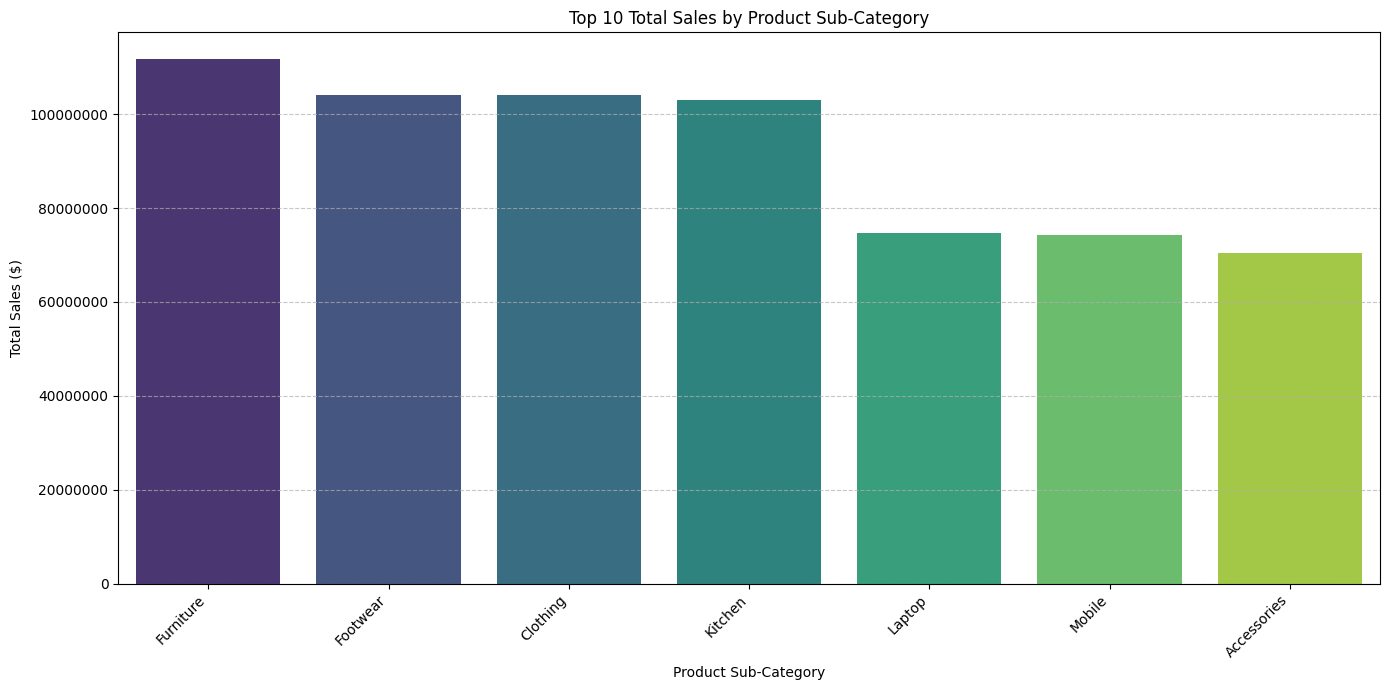

In [12]:
# Calculate total sales by sub-category
sub_category_sales = df.groupby('sub_category')['total_sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='sub_category', y='total_sales', data=sub_category_sales, palette='viridis', hue='sub_category', legend=False)
plt.title('Top 10 Total Sales by Product Sub-Category')
plt.xlabel('Product Sub-Category')
plt.ylabel('Total Sales ($)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sales by Payment Method Visualization

To understand customer preferences and the distribution of sales across different payment methods, we will visualize the total sales for each payment method using a bar chart. This can help in optimizing payment gateways and marketing strategies.

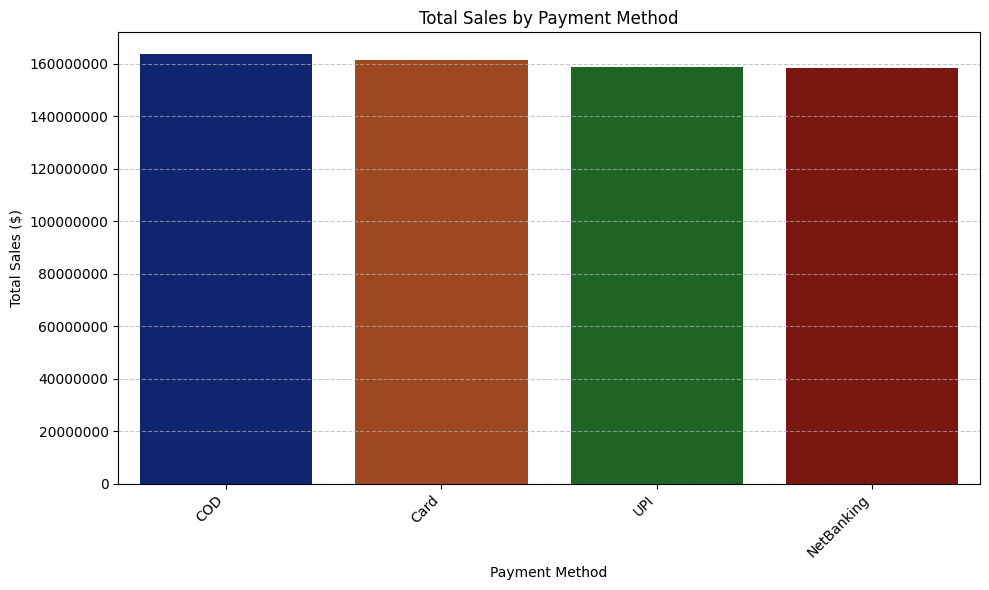

In [13]:
# Calculate total sales by payment method
payment_method_sales = df.groupby('payment_method')['total_sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='payment_method', y='total_sales', data=payment_method_sales, palette='dark', hue='payment_method', legend=False)
plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales ($)')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Order Status Analysis Visualization

To understand the lifecycle and efficiency of our orders, we will visualize the distribution of different `order_status` values using a bar chart. This helps in identifying common statuses and potential areas for operational improvement.

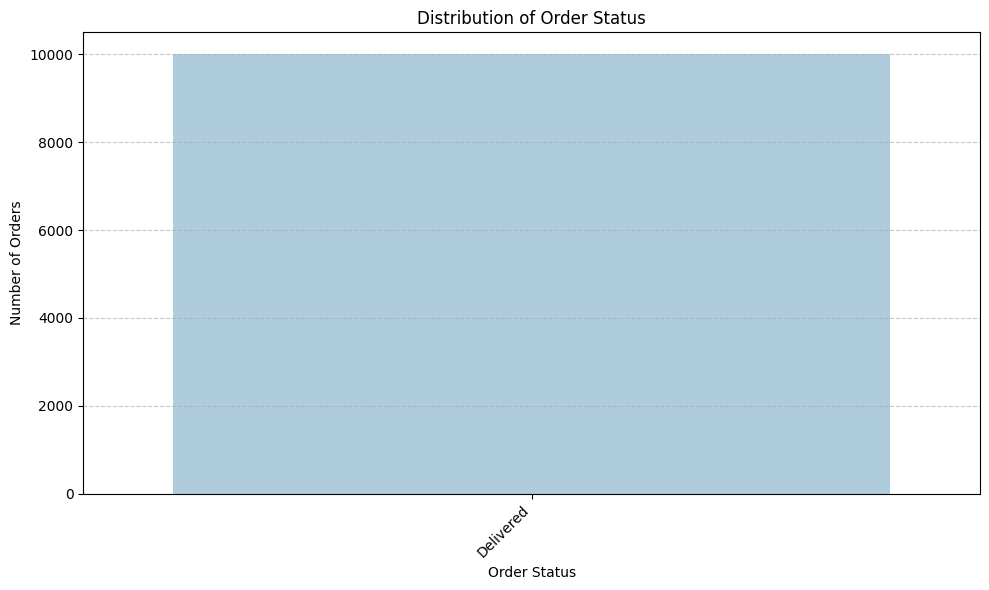

In [14]:
# Calculate the count of each order status
order_status_counts = df['order_status'].value_counts().reset_index()
order_status_counts.columns = ['order_status', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(x='order_status', y='count', data=order_status_counts, palette='Paired', hue='order_status', legend=False)
plt.title('Distribution of Order Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Dashboard Report: Sales Performance & Insights

**Introduction:**
This report provides a clear and concise overview of sales performance, key customer insights, and essential Key Performance Indicators (KPIs) derived from the Amazon sales dataset. The aim is to present actionable findings to stakeholders for informed decision-making.

### 1. Key Performance Indicators (KPIs) for Executives:

*   **Total Sales:** The business achieved a robust total sales figure of 642,129,105.55M.
*   **Average Order Value:** The average order value stands at $64,212.91, indicating a significant value per transaction.
*   **Total Number of Orders:** A total of **10,000** distinct orders were processed within the dataset.

### 2. Sales Overview & Trends:

*   **Monthly Sales Trend:** Analysis shows a clear dominance of sales in **January** (489.99M) over **February** (152.14M). This suggests potential seasonality, promotional activities, or product launches heavily concentrated in the earlier part of the year.
*   **Top Product Categories by Sales:** The leading categories driving sales are:
    1.  **Electronics**: 219.36M
    2.  **Home**: 214.76M
    3.  **Fashion**: 208.01M
    These three categories collectively account for the vast majority of sales.
*   **Top 10 Product Sub-Categories by Sales:** A more granular view reveals:
    *   **Furniture**, **Footwear**, **Clothing**, and **Kitchen** are strong performers, each contributing over 100M in sales.
    *   **Laptop** and **Mobile** are also significant contributors, each exceeding 74M.
*   **Geographical Sales:** The dataset indicates that **India** is the sole and dominant country in terms of sales, reflecting a concentrated market presence or data collection focus.
*   **Sales by Payment Method:** Sales are relatively evenly distributed across payment methods:
    *   **COD (Cash on Delivery):** 163.73M
    *   **Card:** 161.28M
    *   **UPI:** 158.82M
    *   **NetBanking:** 158.30M
    This diversity suggests a broad appeal across various customer payment preferences.

### 3. Customer Insights:

*   **Top 5 Customers by Sales:** Identifying high-value customers is crucial. The top contributors are:
    1.  **Megan Johnson:** 519,128.22
    2.  **John Smith:** 437,475.71
    3.  **Thomas Johnson:** 434,161.24
    4.  **Jason Smith:** 421,137.49
    5.  **Jennifer Brown:** 415,018.88
    These customers represent a significant portion of the total sales and are vital for retention strategies.

### 4. Order Status Analysis:

*   The analysis of order statuses shows that **all 10,000 orders are marked as 'Delivered'**. This indicates a high level of successful order fulfillment or that the dataset primarily captures completed transactions.

### Actionable Recommendations for Stakeholders:

1.  **Strategic Focus on Top Categories:** Continue to prioritize and invest in marketing, product development, and inventory for Electronics, Home, and Fashion categories. Explore opportunities within their top-performing sub-categories (e.g., Furniture, Footwear, Clothing).
2.  **Investigate Monthly Sales Disparity:** Conduct a deeper analysis into the reasons for the significant sales drop from January to February. Was this due to seasonal demand, specific marketing campaigns, or external factors? Understanding this can help in planning future sales strategies and promotions to smooth out sales fluctuations.
3.  **Enhance Customer Retention Programs:** Implement targeted loyalty programs or personalized outreach for the top-performing customers (Megan Johnson, John Smith, etc.) to foster continued engagement and maximize their lifetime value.
4.  **Payment Method Optimization:** The balanced distribution across payment methods suggests flexibility is consistent. Ensure all payment gateways are efficient and secure. Consider leveraging insights from payment method popularity for targeted promotions (e.g., UPI-specific discounts if aiming to increase digital transactions).
5.  **Market Expansion Consideration (if applicable):** Given the singular focus on India in the dataset, if global growth is a business objective, future strategies should involve market research and potential entry into new geographical regions.
6.  **Operational Efficiency Confirmation:** The 100% delivered status for orders suggests strong operational execution, which is a significant asset. Maintain and continuously optimize these fulfillment processes.

By leveraging these insights, stakeholders can make informed decisions to drive sales growth, enhance customer satisfaction, and improve operational efficiency across the business.